# Classificação da Qualidade de Vinhos Tintos

[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1F9UQGQ5DB8tpNhCcxa2RiVcQ5Qi1AByF?usp=sharing)

Este notebook desenvolve um modelo de classificação capaz de identificar vinhos tintos de boa qualidade a partir de propriedades físico-químicas.

**Definição da variável-alvo**

- Classe 1 - vinho bom: nota de qualidade maior ou igual a 7.
- Classe 0 - vinho ruim ou médio: nota de qualidade menor que 7.

O fluxo foi organizado para evitar vazamento de dados: análise e limpeza inicial, divisão estratificada em treino/validação/teste, seleção do modelo sem consultar o teste, avaliação final única e salvamento dos mesmos objetos utilizados pela aplicação Streamlit.

## 1. Bibliotecas e configurações

- pandas e numpy: manipulação dos dados.
- matplotlib e seaborn: visualizações.
- scikit-learn: divisão dos dados, pré-processamento, modelos e métricas.
- joblib: salvamento do modelo treinado.
- pathlib: localização segura dos arquivos em diferentes ambientes.

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

## 2. Carregamento do dataset

A função abaixo procura o arquivo tanto na pasta atual quanto em notebooks/. Isso permite executar o notebook a partir da raiz do projeto, da própria pasta do notebook ou de um ambiente como o Google Colab.

In [2]:
def localizar_dataset(nome_arquivo="winequality-red.csv"):
    candidatos = [
        Path.cwd() / nome_arquivo,
        Path.cwd() / "notebooks" / nome_arquivo,
        Path("/content") / nome_arquivo,
    ]

    for candidato in candidatos:
        if candidato.exists():
            return candidato.resolve()

    encontrados = list(Path.cwd().rglob(nome_arquivo))
    if encontrados:
        return encontrados[0].resolve()

    raise FileNotFoundError(
        f"Arquivo {nome_arquivo!r} não encontrado. "
        "Coloque o dataset na pasta notebooks ou no diretório atual."
    )


DATA_PATH = localizar_dataset()
PROJECT_ROOT = DATA_PATH.parent.parent if DATA_PATH.parent.name == "notebooks" else Path.cwd()
MODEL_DIR = PROJECT_ROOT / "model"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

df_original = pd.read_csv(DATA_PATH)
df = df_original.copy()

print(f"Dataset: {DATA_PATH}")
print(f"Dimensões iniciais: {df.shape[0]} linhas e {df.shape[1]} colunas")
display(df.head())

Dataset: C:\Users\José\Desktop\Projeto_P2\notebooks\winequality-red.csv
Dimensões iniciais: 1599 linhas e 12 colunas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 3. Inspeção inicial

info() apresenta tipos e quantidade de valores preenchidos. describe() resume distribuição, média, dispersão e extremos das variáveis numéricas.

In [3]:
df.info()
display(df.describe().T)

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


## 4. Qualidade e consistência dos dados

São verificadas células vazias, tipos de dados e linhas duplicadas. Linhas exatamente repetidas são removidas antes da divisão para impedir que uma mesma observação apareça simultaneamente no treino e no teste, o que deixaria as métricas artificialmente melhores.

In [4]:
resumo_qualidade = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "valores_ausentes": df.isna().sum(),
    "valores_unicos": df.nunique(),
})

duplicadas = int(df.duplicated().sum())

display(resumo_qualidade)
print(f"Total de valores ausentes: {int(df.isna().sum().sum())}")
print(f"Linhas duplicadas encontradas: {duplicadas}")

linhas_antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)

print(f"Linhas antes da remoção: {linhas_antes}")
print(f"Linhas depois da remoção: {len(df)}")

,tipo,valores_ausentes,valores_unicos
fixed acidity,float64,0,96
volatile acidity,float64,0,143
citric acid,float64,0,80
residual sugar,float64,0,91
chlorides,float64,0,153
free sulfur dioxide,float64,0,60
total sulfur dioxide,float64,0,144
density,float64,0,436
pH,float64,0,89
sulphates,float64,0,96


Total de valores ausentes: 0
Linhas duplicadas encontradas: 240
Linhas antes da remoção: 1599
Linhas depois da remoção: 1359


## 5. Variável-alvo e desbalanceamento

A nota original possui valores de 3 a 8. Para o problema de classificação binária, notas maiores ou iguais a 7 formam a classe positiva. A distribuição percentual é analisada porque a classe de vinhos bons é minoritária; por isso, apenas acurácia não é suficiente para avaliar os modelos.

,quantidade,percentual
target,,
Ruim/Médio (0),1175,86.46
Bom (1),184,13.54


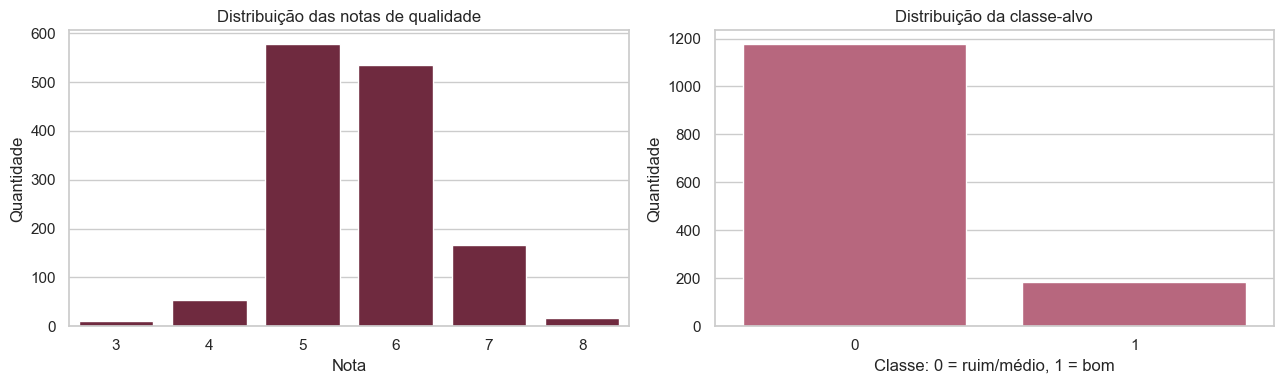

In [5]:
df["target"] = (df["quality"] >= 7).astype(int)

distribuicao_alvo = (
    df["target"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Ruim/Médio (0)", 1: "Bom (1)"})
    .to_frame("quantidade")
)
distribuicao_alvo["percentual"] = (
    distribuicao_alvo["quantidade"] / len(df) * 100
).round(2)

display(distribuicao_alvo)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(data=df, x="quality", color="#7b1e3a", ax=axes[0])
axes[0].set_title("Distribuição das notas de qualidade")
axes[0].set_xlabel("Nota")
axes[0].set_ylabel("Quantidade")

sns.countplot(data=df, x="target", color="#c45a78", ax=axes[1])
axes[1].set_title("Distribuição da classe-alvo")
axes[1].set_xlabel("Classe: 0 = ruim/médio, 1 = bom")
axes[1].set_ylabel("Quantidade")

plt.tight_layout()
plt.show()

## 6. Análise de outliers

O método do intervalo interquartil (IQR) é usado somente para identificar valores extremos. Eles **não são removidos automaticamente**, pois podem representar medições químicas válidas e a exclusão de linhas poderia reduzir ainda mais a classe minoritária.

Essa decisão também evita calcular limites com informações do conjunto de teste. Caso a remoção fosse necessária, seus limites deveriam ser aprendidos exclusivamente no treino ou dentro de um transformador do Pipeline.

,valores_fora_do_IQR
residual sugar,126
chlorides,87
sulphates,55
total sulfur dioxide,45
fixed acidity,41
density,35
pH,28
free sulfur dioxide,26
volatile acidity,19
alcohol,12


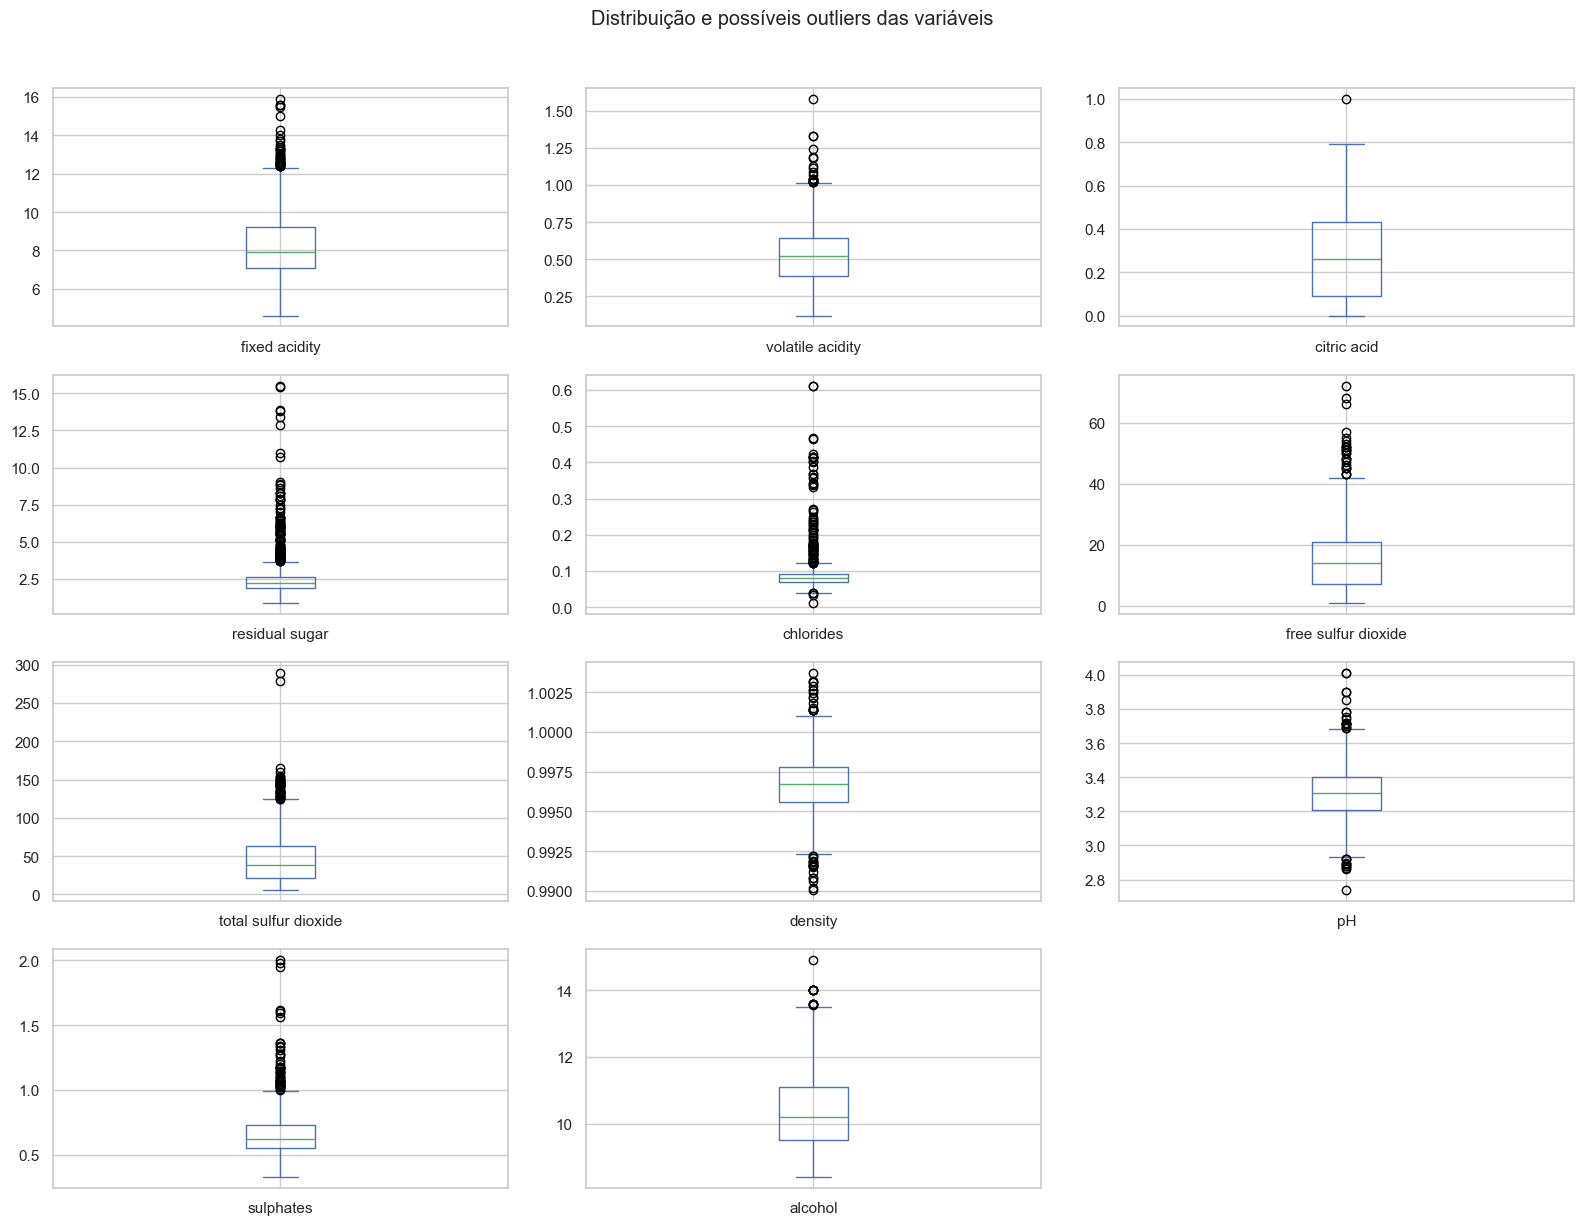

In [6]:
FEATURES = [coluna for coluna in df.columns if coluna not in ["quality", "target"]]

q1 = df[FEATURES].quantile(0.25)
q3 = df[FEATURES].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

quantidade_outliers = (
    (df[FEATURES].lt(limite_inferior) | df[FEATURES].gt(limite_superior))
    .sum()
    .sort_values(ascending=False)
    .to_frame("valores_fora_do_IQR")
)

display(quantidade_outliers)

df[FEATURES].plot(
    kind="box",
    subplots=True,
    layout=(4, 3),
    figsize=(16, 12),
    sharex=False,
    sharey=False,
)
plt.suptitle("Distribuição e possíveis outliers das variáveis", y=1.02)
plt.tight_layout()
plt.show()

## 7. Correlação entre as variáveis

O mapa de calor ajuda a identificar relações lineares. Correlação não implica causalidade, mas permite observar quais propriedades possuem associação positiva ou negativa com a nota e com a classe-alvo.

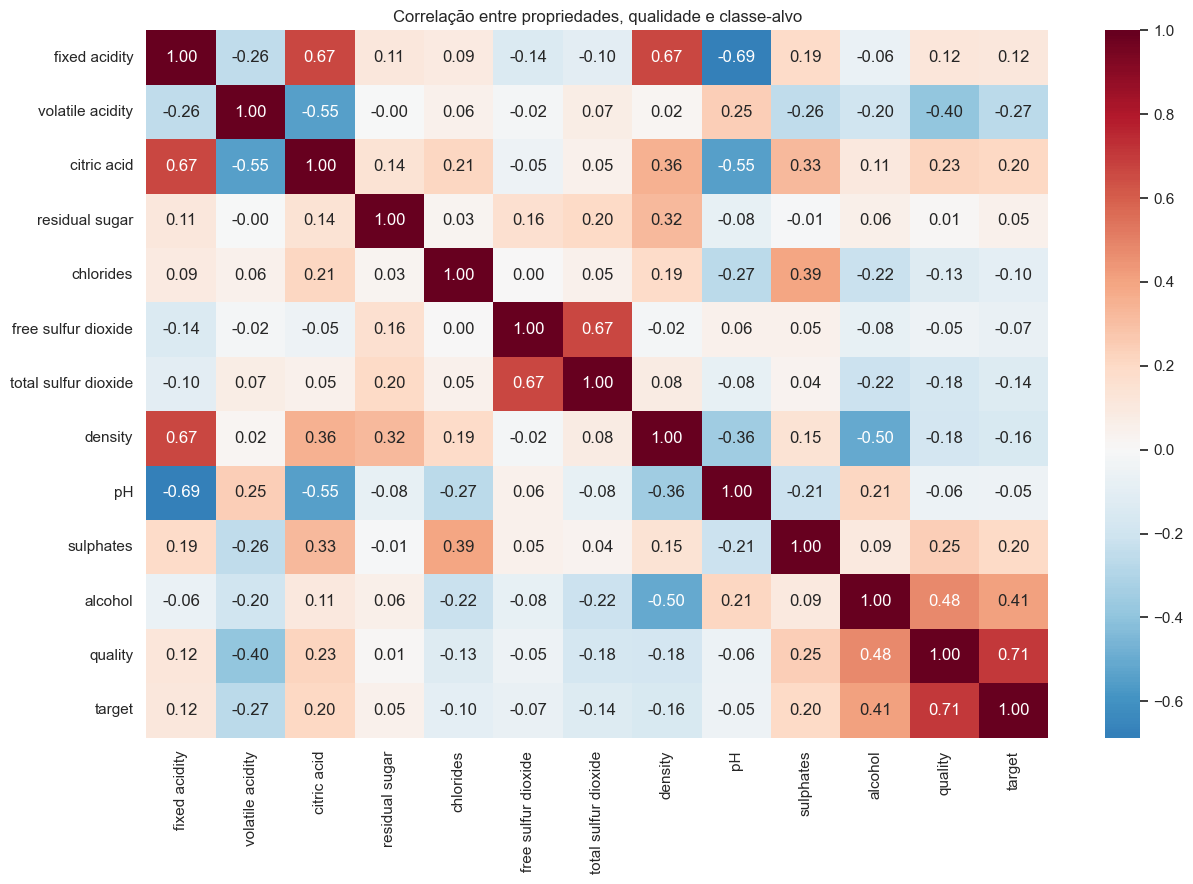

In [7]:
plt.figure(figsize=(13, 9))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
)
plt.title("Correlação entre propriedades, qualidade e classe-alvo")
plt.tight_layout()
plt.show()

## 8. Separação entre treino, validação e teste

- **Treino (60%)**: ajuste dos modelos e validação cruzada.
- **Validação (20%)**: comparação final entre os candidatos e escolha do modelo.
- **Teste (20%)**: avaliação única do modelo escolhido em dados nunca utilizados nas decisões anteriores.

stratify preserva aproximadamente a proporção das classes em todas as divisões. random_state torna o resultado reproduzível.

In [8]:
X = df[FEATURES].copy()
y = df["target"].copy()

X_temporario, X_test, y_temporario, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temporario,
    y_temporario,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_temporario,
)

divisoes = pd.DataFrame({
    "conjunto": ["Treino", "Validação", "Teste"],
    "amostras": [len(X_train), len(X_val), len(X_test)],
    "percentual_classe_positiva": [
        y_train.mean() * 100,
        y_val.mean() * 100,
        y_test.mean() * 100,
    ],
})

display(divisoes.round(2))

,conjunto,amostras,percentual_classe_positiva
0,Treino,815,13.5
1,Validação,272,13.6
2,Teste,272,13.6


## 9. Pipelines e validação cruzada

O StandardScaler e o classificador ficam no mesmo Pipeline. Em cada fold da validação cruzada, o scaler aprende média e desvio padrão apenas com a parte de treino daquele fold, eliminando vazamento de informação.

São comparados:

- **KNN**: classifica pela proximidade entre amostras.
- **SVC**: procura uma fronteira de separação entre as classes.
- **Random Forest**: combina várias árvores de decisão.

SVC e Random Forest usam class_weight="balanced" para dar mais importância à classe minoritária.

In [9]:
modelos = {
    "KNN": Pipeline([
        ("padronizador", StandardScaler()),
        ("modelo", KNeighborsClassifier(n_neighbors=5, weights="distance")),
    ]),
    "SVC": Pipeline([
        ("padronizador", StandardScaler()),
        (
            "modelo",
            SVC(
                probability=True,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]),
    "Random Forest": Pipeline([
        ("padronizador", StandardScaler()),
        (
            "modelo",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]),
}

metricas_cv = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

resultados_cv = []

for nome, pipeline in modelos.items():
    resultado = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=skf,
        scoring=metricas_cv,
        n_jobs=-1,
    )

    resultados_cv.append({
        "Modelo": nome,
        "Acurácia": resultado["test_accuracy"].mean(),
        "Precisão": resultado["test_precision"].mean(),
        "Recall": resultado["test_recall"].mean(),
        "F1-score": resultado["test_f1"].mean(),
        "ROC-AUC": resultado["test_roc_auc"].mean(),
        "Desvio F1": resultado["test_f1"].std(),
    })

resultados_cv_df = (
    pd.DataFrame(resultados_cv)
    .sort_values(["F1-score", "ROC-AUC"], ascending=False)
    .reset_index(drop=True)
)

display(resultados_cv_df.round(3))

,Modelo,Acurácia,Precisão,Recall,F1-score,ROC-AUC,Desvio F1
0,SVC,0.815,0.401,0.745,0.521,0.870,0.015
1,Random Forest,0.861,0.489,0.491,0.488,0.868,0.071
2,KNN,0.863,0.506,0.336,0.400,0.792,0.087


## 10. Comparação no conjunto de validação

Os candidatos são ajustados somente no treino e avaliados na validação. O critério principal de escolha é o **F1-score**, que equilibra precisão e recall e é adequado ao desbalanceamento. Em caso de empate, são usados ROC-AUC e recall.

In [10]:
resultados_validacao = []
modelos_validacao = {}

for nome, pipeline in modelos.items():
    pipeline_ajustado = clone(pipeline)
    pipeline_ajustado.fit(X_train, y_train)
    modelos_validacao[nome] = pipeline_ajustado

    y_val_pred = pipeline_ajustado.predict(X_val)
    y_val_proba = pipeline_ajustado.predict_proba(X_val)[:, 1]

    resultados_validacao.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_val, y_val_pred),
        "Precisão": precision_score(y_val, y_val_pred, zero_division=0),
        "Recall": recall_score(y_val, y_val_pred, zero_division=0),
        "F1-score": f1_score(y_val, y_val_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val, y_val_proba),
    })

resultados_validacao_df = (
    pd.DataFrame(resultados_validacao)
    .sort_values(
        ["F1-score", "ROC-AUC", "Recall"],
        ascending=False,
    )
    .reset_index(drop=True)
)

modelo_escolhido = resultados_validacao_df.loc[0, "Modelo"]

display(resultados_validacao_df.round(3))
print(f"Modelo escolhido pela validação: {modelo_escolhido}")

,Modelo,Acurácia,Precisão,Recall,F1-score,ROC-AUC
0,SVC,0.816,0.411,0.811,0.545,0.876
1,Random Forest,0.860,0.486,0.486,0.486,0.884
2,KNN,0.868,0.519,0.378,0.438,0.820


Modelo escolhido pela validação: SVC


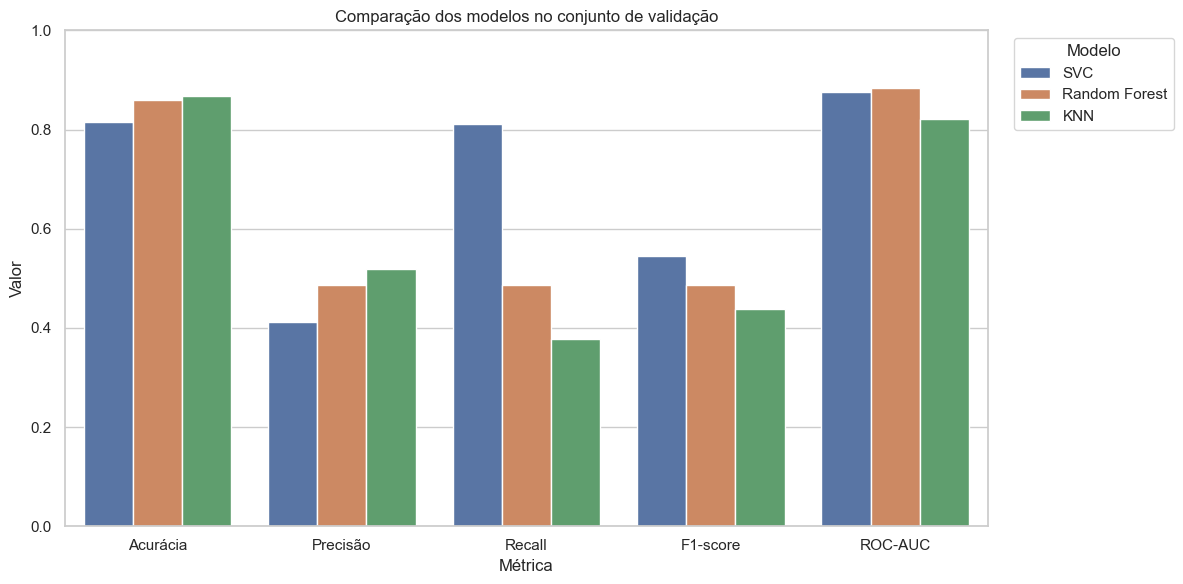

In [11]:
metricas_longas = resultados_validacao_df.melt(
    id_vars="Modelo",
    var_name="Métrica",
    value_name="Valor",
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=metricas_longas,
    x="Métrica",
    y="Valor",
    hue="Modelo",
)
plt.ylim(0, 1)
plt.title("Comparação dos modelos no conjunto de validação")
plt.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 10.1 Matrizes de confusão dos modelos na validação

As matrizes abaixo mostram os acertos e erros de KNN, SVC e Random Forest no conjunto de validação. Essa comparação visual é feita antes da escolha final e sem consultar o teste.

- **Verdadeiro negativo:** vinho ruim/médio classificado corretamente.
- **Falso positivo:** vinho ruim/médio classificado como bom.
- **Falso negativo:** vinho bom não identificado.
- **Verdadeiro positivo:** vinho bom identificado corretamente.

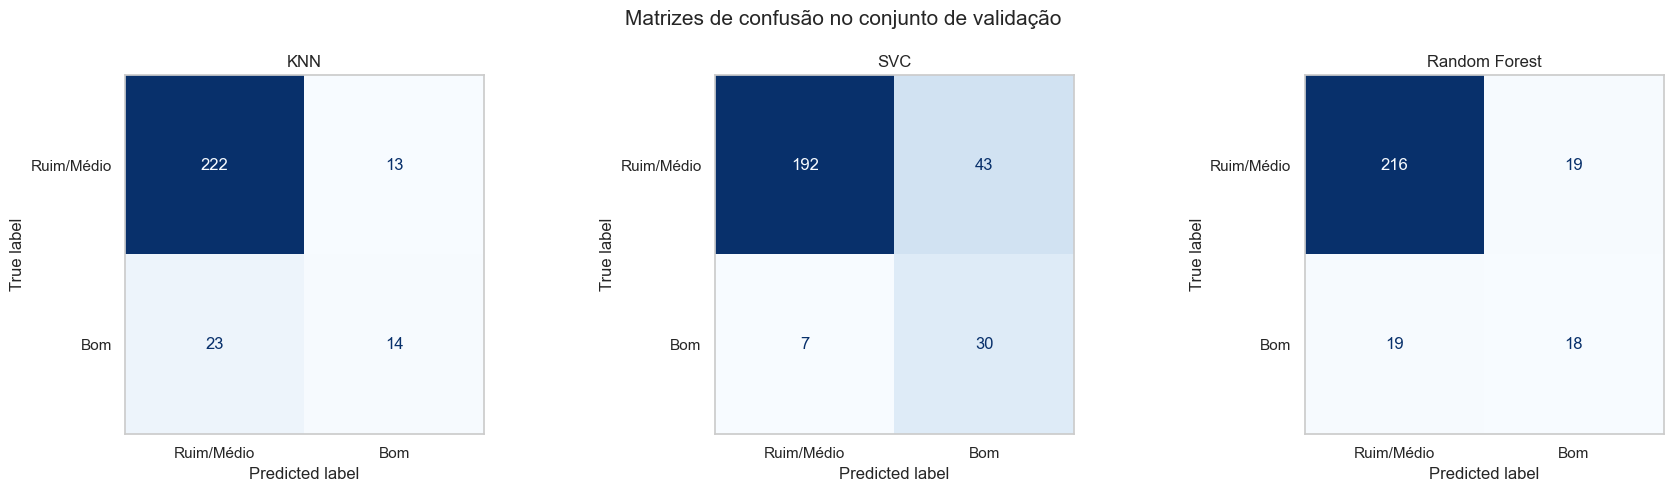

In [12]:
fig, axes = plt.subplots(1, len(modelos_validacao), figsize=(18, 5))

for eixo, (nome, pipeline_ajustado) in zip(axes, modelos_validacao.items()):
    previsao_validacao = pipeline_ajustado.predict(X_val)
    matriz_validacao = confusion_matrix(y_val, previsao_validacao)

    ConfusionMatrixDisplay(
        confusion_matrix=matriz_validacao,
        display_labels=["Ruim/Médio", "Bom"],
    ).plot(
        ax=eixo,
        cmap="Blues",
        values_format="d",
        colorbar=False,
    )
    eixo.set_title(nome)
    eixo.grid(False)

fig.suptitle("Matrizes de confusão no conjunto de validação", fontsize=15)
plt.tight_layout()
plt.show()

### 10.2 Curvas ROC dos modelos na validação

A curva ROC compara a taxa de verdadeiros positivos com a taxa de falsos positivos em vários limiares. Quanto mais próxima do canto superior esquerdo e maior a área sob a curva (AUC), melhor a capacidade de separação entre as classes.

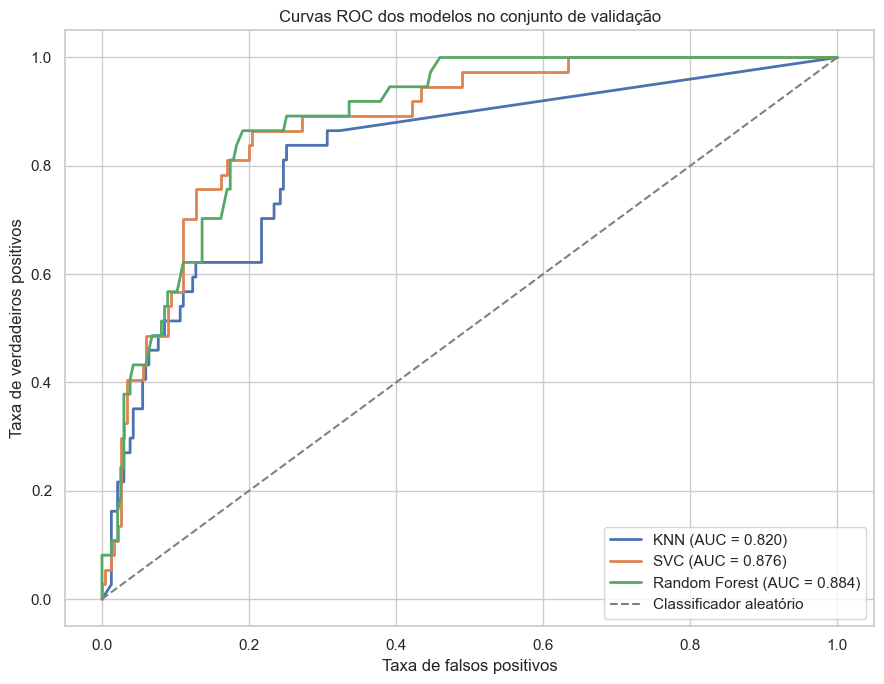

In [13]:
plt.figure(figsize=(9, 7))

for nome, pipeline_ajustado in modelos_validacao.items():
    probabilidade_validacao = pipeline_ajustado.predict_proba(X_val)[:, 1]
    fpr_validacao, tpr_validacao, _ = roc_curve(
        y_val,
        probabilidade_validacao,
    )
    auc_validacao = roc_auc_score(y_val, probabilidade_validacao)

    plt.plot(
        fpr_validacao,
        tpr_validacao,
        linewidth=2,
        label=f"{nome} (AUC = {auc_validacao:.3f})",
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Classificador aleatório",
)
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos")
plt.title("Curvas ROC dos modelos no conjunto de validação")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 11. Treinamento e avaliação final

Depois da escolha, o modelo selecionado é treinado novamente com a união de treino e validação. Só então o conjunto de teste é consultado uma única vez. Assim, as métricas finais representam melhor a capacidade de generalização para dados desconhecidos.

In [14]:
X_desenvolvimento = pd.concat([X_train, X_val], axis=0)
y_desenvolvimento = pd.concat([y_train, y_val], axis=0)

modelo_final = clone(modelos[modelo_escolhido])
modelo_final.fit(X_desenvolvimento, y_desenvolvimento)

y_test_pred = modelo_final.predict(X_test)
y_test_proba = modelo_final.predict_proba(X_test)[:, 1]

metricas_teste = pd.Series({
    "Acurácia": accuracy_score(y_test, y_test_pred),
    "Precisão": precision_score(y_test, y_test_pred, zero_division=0),
    "Recall": recall_score(y_test, y_test_pred, zero_division=0),
    "F1-score": f1_score(y_test, y_test_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba),
}, name="Teste final")

print(f"Modelo final: {modelo_escolhido}")
display(metricas_teste.to_frame().round(3))
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Ruim/Médio", "Bom"],
        zero_division=0,
    )
)

Modelo final: SVC


,Teste final
Acurácia,0.805
Precisão,0.392
Recall,0.784
F1-score,0.523
ROC-AUC,0.884


              precision    recall  f1-score   support

  Ruim/Médio       0.96      0.81      0.88       235
         Bom       0.39      0.78      0.52        37

    accuracy                           0.81       272
   macro avg       0.68      0.80      0.70       272
weighted avg       0.88      0.81      0.83       272



### Interpretação das métricas

- **Acurácia**: proporção total de previsões corretas.
- **Precisão**: entre os vinhos previstos como bons, quantos realmente eram bons.
- **Recall**: entre os vinhos realmente bons, quantos foram identificados.
- **F1-score**: equilíbrio entre precisão e recall.
- **ROC-AUC**: capacidade de ordenar casos positivos acima dos negativos em vários limiares.

Em dados desbalanceados, F1, recall e ROC-AUC devem receber mais atenção que a acurácia isolada.

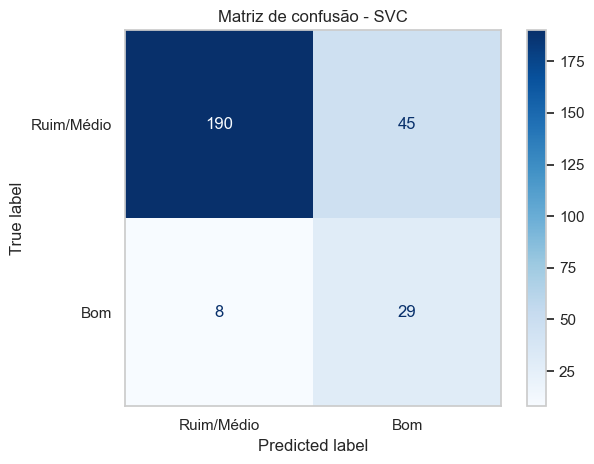

In [15]:
matriz = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["Ruim/Médio", "Bom"],
)
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Matriz de confusão - {modelo_escolhido}")
plt.grid(False)
plt.tight_layout()
plt.show()

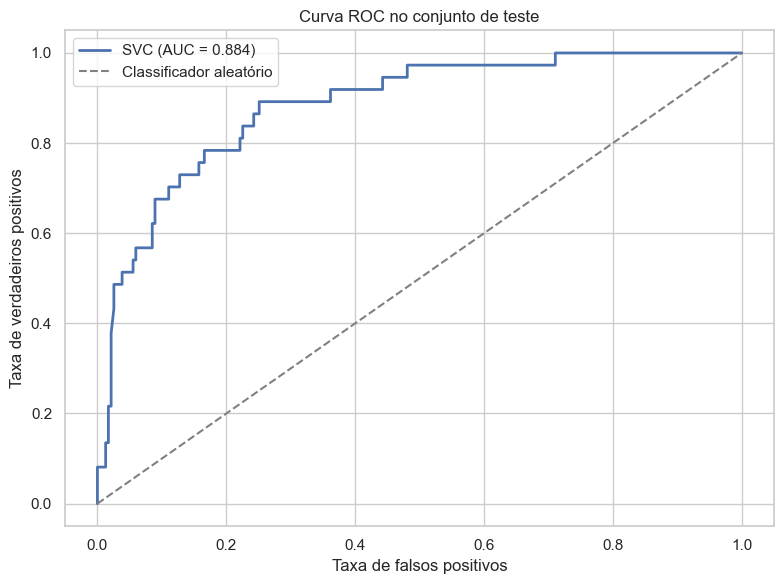

In [16]:
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
auc_teste = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"{modelo_escolhido} (AUC = {auc_teste:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Classificador aleatório")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos")
plt.title("Curva ROC no conjunto de teste")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Importância das variáveis

A importância por permutação mede quanto o F1-score piora quando os valores de uma variável são embaralhados. Ela funciona para qualquer um dos três modelos e evita limitar a análise apenas ao Random Forest.

,Variável,Importância média,Desvio
0,alcohol,0.1050,0.0328
1,sulphates,0.0732,0.0287
2,volatile acidity,0.0255,0.0298
3,chlorides,0.0220,0.0163
4,citric acid,0.0095,0.0235
5,density,0.0081,0.0177
6,free sulfur dioxide,0.0071,0.0170
7,total sulfur dioxide,0.0062,0.0361
8,residual sugar,-0.0005,0.0101
9,pH,-0.0039,0.0129


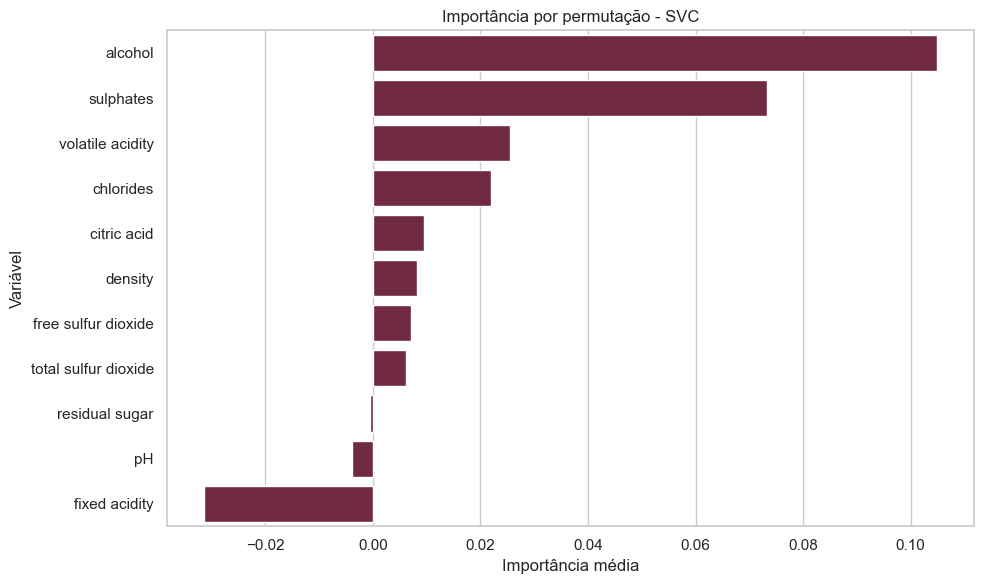

In [17]:
importancia = permutation_importance(
    modelo_final,
    X_test,
    y_test,
    scoring=make_scorer(f1_score, zero_division=0),
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importancia_df = (
    pd.DataFrame({
        "Variável": FEATURES,
        "Importância média": importancia.importances_mean,
        "Desvio": importancia.importances_std,
    })
    .sort_values("Importância média", ascending=False)
    .reset_index(drop=True)
)

display(importancia_df.round(4))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importancia_df,
    x="Importância média",
    y="Variável",
    color="#7b1e3a",
)
plt.title(f"Importância por permutação - {modelo_escolhido}")
plt.tight_layout()
plt.show()

## 13. Salvamento dos artefatos

São salvos:

- o Pipeline completo, opção mais segura para reutilização;
- o classificador e o scaler separadamente, mantendo compatibilidade com a aplicação;
- metadados com variáveis, critério de escolha, métricas e versões.

Os arquivos salvos abaixo correspondem exatamente ao modelo avaliado no conjunto de teste.

In [18]:
pipeline_path = MODEL_DIR / "pipeline_vinhos_final.pkl"
modelo_path = MODEL_DIR / "modelo_vinhos_final.pkl"
scaler_path = MODEL_DIR / "scaler_vinhos.pkl"
metadata_path = MODEL_DIR / "metadata_modelo.json"

joblib.dump(modelo_final, pipeline_path)
joblib.dump(modelo_final.named_steps["modelo"], modelo_path)
joblib.dump(modelo_final.named_steps["padronizador"], scaler_path)

metadata_modelo = {
    "modelo_escolhido": modelo_escolhido,
    "criterio_selecao": "Maior F1-score na validação; desempate por ROC-AUC e recall",
    "target": "1 quando quality >= 7; 0 quando quality < 7",
    "features": FEATURES,
    "metricas_teste": {chave: float(valor) for chave, valor in metricas_teste.items()},
    "versoes": {
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scikit_learn": sklearn.__version__,
        "joblib": joblib.__version__,
    },
}

with metadata_path.open("w", encoding="utf-8") as arquivo:
    json.dump(metadata_modelo, arquivo, ensure_ascii=False, indent=2)

print("Artefatos salvos:")
for caminho in [pipeline_path, modelo_path, scaler_path, metadata_path]:
    print(f"- {caminho}")

Artefatos salvos:
- C:\Users\José\Desktop\Projeto_P2\model\pipeline_vinhos_final.pkl
- C:\Users\José\Desktop\Projeto_P2\model\modelo_vinhos_final.pkl
- C:\Users\José\Desktop\Projeto_P2\model\scaler_vinhos.pkl
- C:\Users\José\Desktop\Projeto_P2\model\metadata_modelo.json


## 14. Conclusão e limitações

O modelo final é escolhido de forma objetiva pelo F1-score no conjunto de validação e avaliado apenas uma vez no teste. O uso de Pipeline, divisão estratificada e classes balanceadas reduz riscos metodológicos e torna o treinamento reproduzível.

**Limitações**

- A classe de vinhos bons é minoritária.
- A definição binária simplifica notas de qualidade diferentes em apenas duas classes.
- O dataset contém somente vinhos tintos de uma origem específica.
- A qualidade sensorial não depende apenas das propriedades químicas disponíveis.
- Uma previsão auxilia a análise, mas não substitui a avaliação de especialistas.

Os resultados devem ser interpretados em conjunto, com atenção especial ao F1-score, recall, ROC-AUC e à matriz de confusão.